# 2D FEM Solver

We aim to solve the differential linear equation

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

on the area given by the following image.

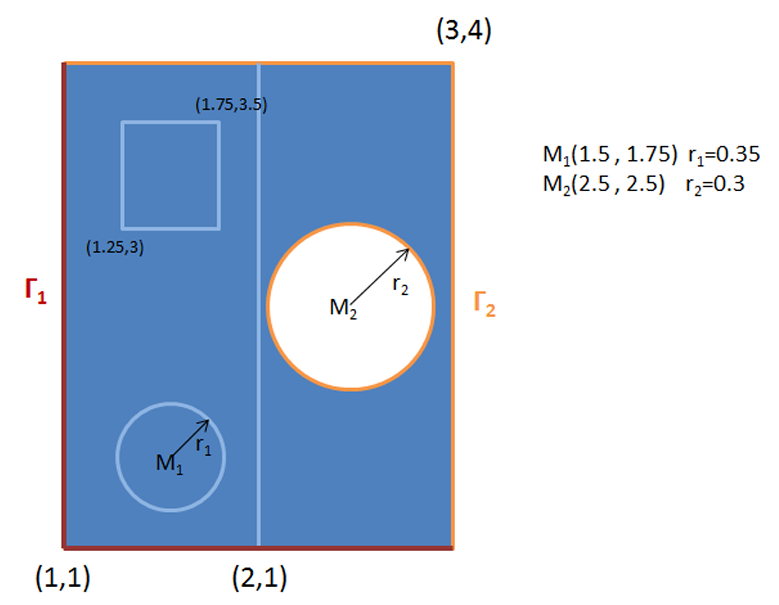

## Robin

\begin{equation}
\Phi(x, y) = x^2 -y^2 +1 \quad x,y \in \Gamma_2
\end{equation}

\begin{equation}
\left( \alpha_1 \frac{\partial \Phi}{\partial x}, \alpha_2 \frac{\partial \Phi}{\partial x} \right) \vec{n} + 3xy \Phi = 20 \quad x,y \in \Gamma_1
\end{equation}

In [1]:
import numpy as np

import functions as myfunc

## Assign Paramters from Task

In [2]:
DOMAIN_KNOTS = np.loadtxt("Lösung/Netz2D_p.dat")
ELEMENTS = np.loadtxt("Lösung/Netz2D_t.dat", dtype=int) # ! dtype is important here.

def alpha1(x, y):
    if 1.25 <= x <= 1.75 and 3 <= y <= 3.5:
        return 0.01
    else:
        return 5 * y * np.power(x, 2)
    
def alpha2(x, y):
    return np.power(y, 2)

def beta(x, y):
    left_hand_side = np.power((x-1.5),2) + np.power((y-1.75), 2) 
    if left_hand_side <= 0.35**2:
        return 500
    else:
        return 5
    
def rhs(x, y):
    if x >= 2:
        return -10 * x * y
    else:
        return 0
    
# Dirichlet Boundary Conditions
DIRICHLET_INDICES = np.loadtxt("Lösung/Netz2D_dr_b).dat", dtype=int)
def dirichlet(x, y):
    return np.power(x, 2) - np.power(y, 2) + 1

# Robin Boundary Conditions
ROBIN_INDICES = np.loadtxt("Lösung/Netz2D_rr_b).dat", dtype=int)
def robin_gamma(x, y):
    return 3 * x * y

def robin_rhs(x, y):
    return 20

In [3]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)

In [4]:
stiffness_matrix, load_vector = myfunc.insert_robin_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)

In [5]:
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet)

In [6]:
solution = myfunc.solve_system(DOMAIN_KNOTS, stiffness_matrix, load_vector)

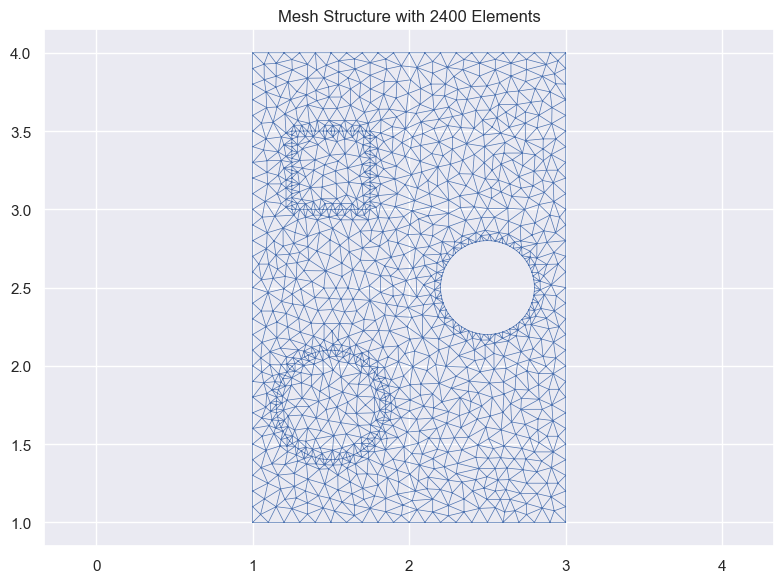

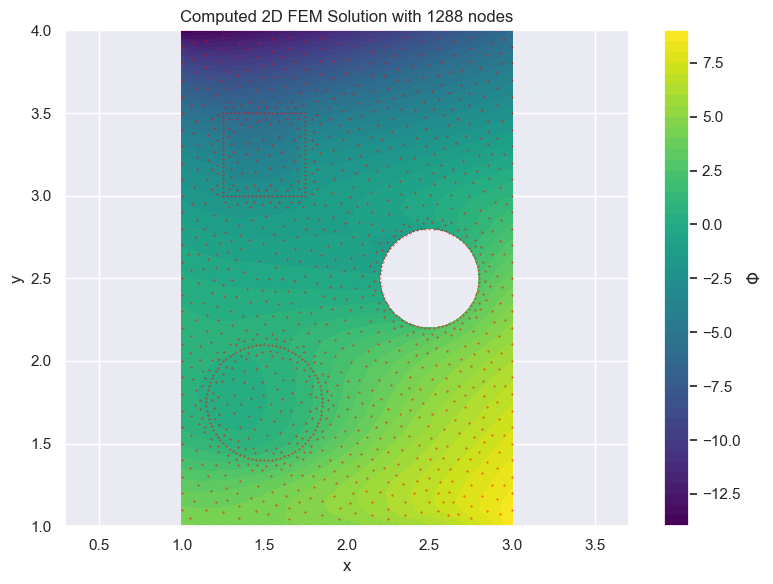

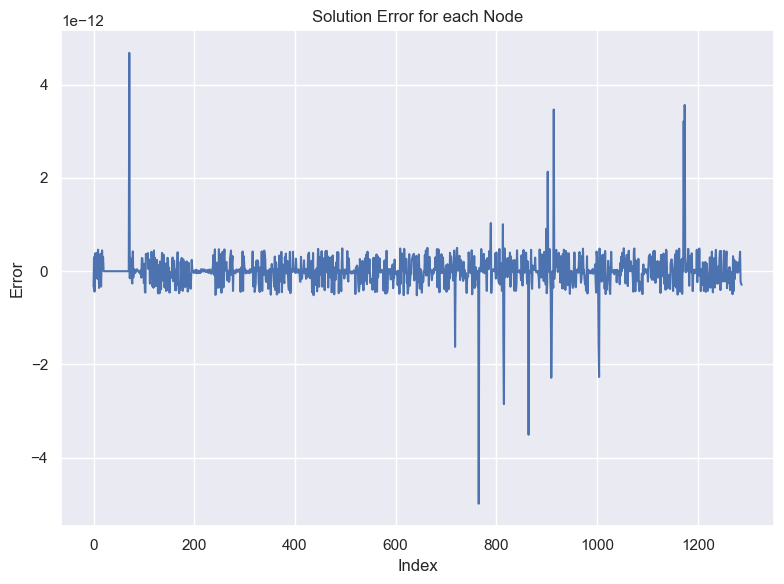

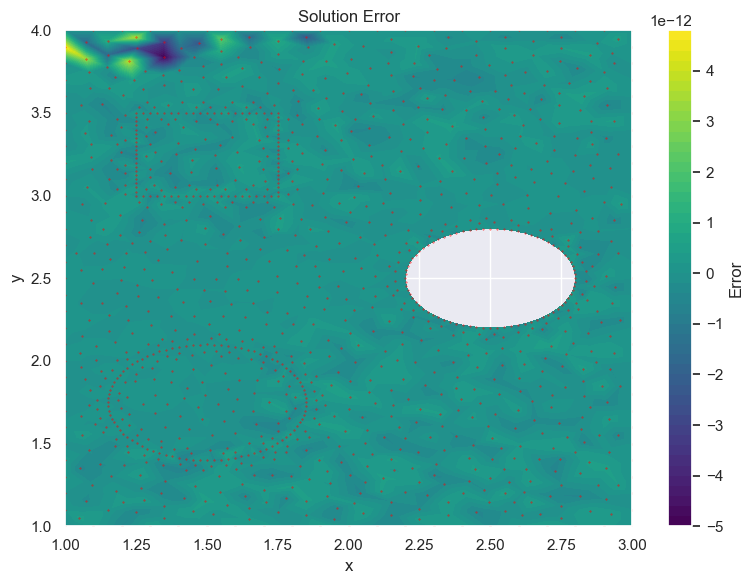

In [7]:
myfunc.plot_result(ELEMENTS, solution, "Lösung/Netz2D_LoesungB.dat", levels=50)